# Visualize Transformer Results

Load the confusion matrix saved by `TPrime_transformer_train.py` and turn it into an annotated heatmap.

In [ ]:
from pathlib import Path
import numpy as np

# Update these paths if you saved the run elsewhere
RUN_DIR = Path("../TPrime_transformer/model_cp/CLEAN_FY-HO-ON_4000ea")
CONF_MATRIX_FILENAME = "conf_matrix.best.pkl"
DATA_ROOT = Path("../data/CLEAN_FY-HO-ON_12000_train")  # used to infer class labels

print(f"Run directory: {RUN_DIR.resolve()}")

Run directory: /home/sat3737/Projects/t-prime/TPrime_transformer/model_cp/CLEAN_HO_4000


In [6]:
import pickle

conf_matrix_path = (RUN_DIR / CONF_MATRIX_FILENAME).resolve()
if not conf_matrix_path.exists():
    raise FileNotFoundError(f"Could not find {conf_matrix_path}")

with conf_matrix_path.open("rb") as f:
    cm_raw = pickle.load(f)

cm_raw = np.asarray(cm_raw, dtype=np.float64)
total = cm_raw.sum()
overall_accuracy = float(np.trace(cm_raw) / total) if total > 0 else 0.0
cm_norm = cm_raw / cm_raw.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)
cm_percent = cm_norm * 100.0
print(f"Confusion matrix shape: {cm_percent.shape}")
print(f"Overall accuracy: {overall_accuracy * 100:.2f}%")


Confusion matrix shape: (6, 6)
Overall accuracy: 86.57%


In [7]:
def infer_labels(data_root: Path, expected: int):
    if data_root is None:
        return [f"Class {i}" for i in range(expected)]
    if data_root.exists():
        dirs = sorted([p.name for p in data_root.iterdir() if p.is_dir() and not p.name.startswith('.')])
        if len(dirs) == expected:
            return dirs
    return [f"Class {i}" for i in range(expected)]

labels = infer_labels(DATA_ROOT, cm_percent.shape[0])
labels

['AIR', 'INS', 'MIN', 'MP1', 'MP2', 'PHA']

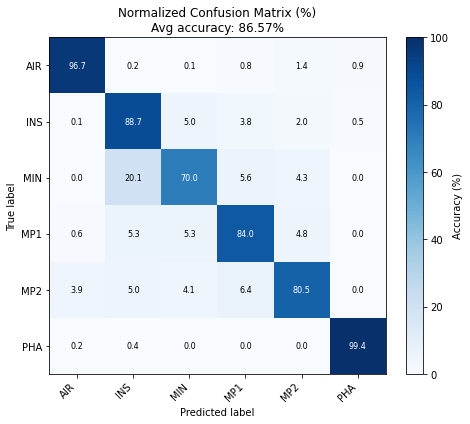

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_percent, cmap="Blues", vmin=0, vmax=100)
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title(f"Normalized Confusion Matrix (%)\nAvg accuracy: {overall_accuracy * 100:.2f}%")

for i in range(cm_percent.shape[0]):
    for j in range(cm_percent.shape[1]):
        value = cm_percent[i, j]
        text_color = "white" if value > 60 else "black"
        ax.text(j, i, f"{value:.1f}", ha="center", va="center", color=text_color, fontsize=8)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Accuracy (%)")
plt.tight_layout()
plt.show()